# Mapping biodiversity across the Pantanal sites

This notebook turns the model's per-segment species detections into a spatial and temporal picture of biodiversity: diversity indices per site, and per time of day within each site, computed from both the ground-truth labels and the model predictions so the gap between them can be measured.

The first step is to establish what spatial resolution is actually possible, by checking whether the dataset provides per-site coordinates or only a regional bounding box.

In [2]:
import pandas as pd
import numpy as np
import json
import os

train = pd.read_csv('../data/train.csv')
ss = pd.read_csv('../data/train_soundscapes_labels.csv')

# 1. does the soundscape labels file carry any coordinate columns?
coord_cols = [c for c in ss.columns if c.lower() in ('latitude','longitude','lat','lon','lng')]
print("coordinate columns in soundscape labels:", coord_cols if coord_cols else "NONE")

# 2. the recording_location.txt bounding box, for reference
print()
print(open('../data/recording_location.txt').read())

# 3. any other metadata files that might hold per-site coords?
print("files in data/:")
for f in sorted(os.listdir('../data')):
    if f.endswith(('.csv', '.txt', '.json')):
        print("  ", f)

coordinate columns in soundscape labels: NONE

Pantanal, Mato Grosso do Sul, Brazil, South America

More info: https://en.wikipedia.org/wiki/Pantanal

Coordinates of recorder deployment sites:

Latitude: -16.5 to -21.6
Longitude: -55.9 to -57.6
files in data/:
   focal_labels.json
   full_meta.json
   recording_location.txt
   taxonomy.csv
   toy_classes.json
   train.csv
   train_soundscapes_labels.csv


## Spatial resolution: site-level, positions approximate

The dataset provides no per-site coordinates, only a regional bounding box for the whole deployment (latitude -16.5 to -21.6, longitude -55.9 to -57.6, Pantanal, Mato Grosso do Sul). Withholding precise recorder locations is common practice in biodiversity monitoring, since exact positions of rare species can enable poaching or disturbance, which is the dual-use concern noted in this project's ethics.

The map is therefore built at site level, with the nine sites placed at approximate positions within the known deployment area rather than at exact recorder coordinates. Distances and adjacency between sites are indicative, not precise, and spatial claims are qualified accordingly.

## From probabilities to presence

The model outputs a probability per species per segment. Counting how many species are present requires a threshold above which a species is called present. This choice directly affects every diversity number, so it is made deliberately rather than defaulting to 0.5.

The threshold is chosen to balance missing real species against inventing absent ones, using the per-species behaviour seen in evaluation. A single global threshold is used first for simplicity, and its effect is examined rather than assumed.

In [3]:
# load the baseline predictions and truth, aligned to the 47 trainable species
ss_emb = np.load('../data/soundscape_embeddings.npy')
with open('../data/full_meta.json') as f:
    meta = json.load(f)
ss_labels = meta['labels']
ss_sites = np.array(meta['sites'])

# rebuild the baseline model's predictions (fast, so we regenerate rather than store)
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

focal_emb = np.load('../data/focal_embeddings.npy')
focal_labels = json.load(open('../data/focal_labels.json'))
species = sorted(set(focal_labels))
mlb = MultiLabelBinarizer(classes=species); mlb.fit([species])

scaler = StandardScaler()
Xtr = scaler.fit_transform(focal_emb)
Xev = scaler.transform(ss_emb)
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'), n_jobs=-1)
clf.fit(Xtr, mlb.transform([[l] for l in focal_labels]))

pred_prob = clf.predict_proba(Xev)      # predicted probabilities per segment
true_Y = mlb.transform(ss_labels)       # ground-truth presence per segment

print("pred_prob:", pred_prob.shape, "| true_Y:", true_Y.shape)
print("sites:", sorted(set(ss_sites)))

pred_prob: (1478, 47) | true_Y: (1478, 47)
sites: [np.str_('S03'), np.str_('S08'), np.str_('S09'), np.str_('S13'), np.str_('S15'), np.str_('S18'), np.str_('S19'), np.str_('S22'), np.str_('S23')]


c:\dev\biodiversity\mapping-biodiversity-from-sound\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1016: UserWarning: unknown class(es) ['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '517063'] will be ignored
  warnings.warn(


## Choosing the presence threshold

Rather than default to 0.5, the threshold is swept across a range. For each value, total predicted species richness across all segments is compared to the true richness. This shows which threshold brings predicted diversity closest to reality, and reveals whether the model tends to over-count or under-count species overall.

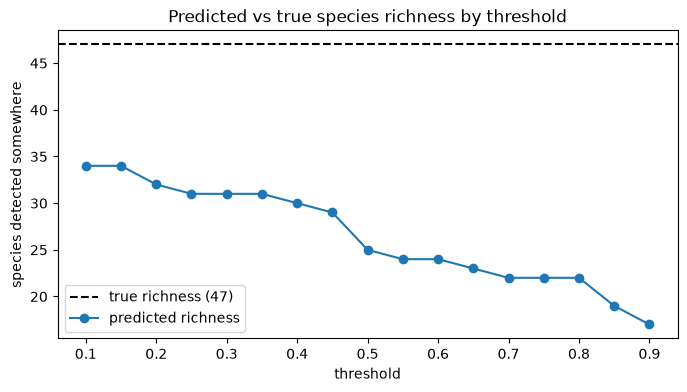

threshold 0.10  ->  34 species predicted present
threshold 0.15  ->  34 species predicted present
threshold 0.20  ->  32 species predicted present
threshold 0.25  ->  31 species predicted present
threshold 0.30  ->  31 species predicted present
threshold 0.35  ->  31 species predicted present
threshold 0.40  ->  30 species predicted present
threshold 0.45  ->  29 species predicted present
threshold 0.50  ->  25 species predicted present
threshold 0.55  ->  24 species predicted present
threshold 0.60  ->  24 species predicted present
threshold 0.65  ->  23 species predicted present
threshold 0.70  ->  22 species predicted present
threshold 0.75  ->  22 species predicted present
threshold 0.80  ->  22 species predicted present
threshold 0.85  ->  19 species predicted present
threshold 0.90  ->  17 species predicted present


In [4]:
import matplotlib.pyplot as plt

true_total = (true_Y.sum(axis=0) > 0).sum()   # species truly present anywhere

thresholds = np.arange(0.1, 0.95, 0.05)
pred_totals = []
for t in thresholds:
    present = (pred_prob >= t)
    pred_totals.append((present.sum(axis=0) > 0).sum())

plt.figure(figsize=(8,4))
plt.axhline(true_total, color='k', ls='--', label=f'true richness ({true_total})')
plt.plot(thresholds, pred_totals, marker='o', label='predicted richness')
plt.xlabel('threshold'); plt.ylabel('species detected somewhere')
plt.legend(); plt.title('Predicted vs true species richness by threshold')
plt.show()

for t, p in zip(thresholds, pred_totals):
    print(f"threshold {t:.2f}  ->  {p} species predicted present")

## Finding: predicted richness cannot reach true richness

Predicted species richness never reaches the true total of 47, at any threshold. At the most permissive threshold it recovers 34 species, falling as the threshold rises. There is no threshold at which the model recovers the true count, because 28 of the species present in the field have no training audio and cannot be detected at all, and several trainable species are also missed.

This means any diversity estimate built on the model's predictions systematically undercounts, by construction rather than by tuning. The size of that undercount is quantified per site later, and is the core reliability limitation of the mapped diversity.

A threshold of 0.3 is used going forward. It retains most of the detectable species while remaining high enough to limit false positives from the permissive low end. The effect of this choice is revisited rather than treated as neutral.

In [5]:
THRESHOLD = 0.30
pred_present = (pred_prob >= THRESHOLD).astype(int)

print("threshold:", THRESHOLD)
print("mean species predicted present per segment:", round(pred_present.sum(axis=1).mean(), 2))
print("mean species truly present per segment:", round(true_Y.sum(axis=1).mean(), 2))

threshold: 0.3
mean species predicted present per segment: 0.77
mean species truly present per segment: 2.91


## The site-by-time grid

Each segment carries a site and a recording hour. Segments are grouped into three periods (night, dawn, dusk) to match the dataset's coverage, giving a grid of up to nine sites by three periods. For every cell, diversity is computed twice: once from the true labels and once from the model's predictions at the chosen threshold. The gap between the two is the reliability layer.

In [6]:
import re

# recover the recording hour for each segment from its source filename
ss_files = meta['files'] if 'files' in meta else None

# if files not in meta, rebuild hour from the labels table order
labels_tbl = pd.read_csv('../data/train_soundscapes_labels.csv')
file_order = []
for fname in labels_tbl['filename'].unique():
    n = (labels_tbl['filename'] == fname).sum()
    file_order += [fname] * n
hours = np.array([int(re.search(r'_(\d{6})\.ogg$', f).group(1)[:2]) for f in file_order])

def period(h):
    if 4 <= h <= 8:   return 'dawn'
    if 17 <= h <= 21: return 'dusk'
    return 'night'

periods = np.array([period(h) for h in hours])
print("segments per period:", {p: int((periods==p).sum()) for p in ['night','dawn','dusk']})
print("hours present:", sorted(set(hours)))

segments per period: {'night': 782, 'dawn': 240, 'dusk': 456}
hours present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## Filling the grid

For each site and period, the segments in that cell are pooled and three diversity measures are computed: species richness (how many species present), Shannon (accounts for evenness), and Simpson (weights dominant species). Each is computed twice, from the true labels and from the model's predictions, so predicted diversity can be set against actual diversity in every cell.

In [8]:
def shannon(counts):
    c = counts[counts > 0]
    if c.sum() == 0: return 0.0
    p = c / c.sum()
    return float(-(p * np.log(p)).sum())

def simpson(counts):
    c = counts[counts > 0]
    n = c.sum()
    if n == 0: return 0.0
    p = c / n
    return float(1 - (p**2).sum())

def diversity(presence_matrix):
    # presence_matrix: segments x species (0/1) for one cell
    counts = presence_matrix.sum(axis=0)      # detections per species
    richness = int((counts > 0).sum())
    return richness, shannon(counts), simpson(counts)

rows = []
for site in sorted(set(ss_sites)):
    for per in ['night', 'dawn', 'dusk']:
        idx = np.where((ss_sites == site) & (periods == per))[0]
        if len(idx) == 0:
            continue
        tr_rich, tr_sh, tr_si = diversity(true_Y[idx])
        pr_rich, pr_sh, pr_si = diversity(pred_present[idx])
        rows.append({
            'site': site, 'period': per, 'n_segments': len(idx),
            'true_richness': tr_rich, 'pred_richness': pr_rich,
            'true_shannon': round(tr_sh, 3), 'pred_shannon': round(pr_sh, 3),
            'true_simpson': round(tr_si, 3), 'pred_simpson': round(pr_si, 3),
        })

grid = pd.DataFrame(rows)
print(grid.to_string(index=False))

grid.to_csv('../data/diversity_grid.csv', index=False)
print("saved grid:", grid.shape)

site period  n_segments  true_richness  pred_richness  true_shannon  pred_shannon  true_simpson  pred_simpson
 S03  night          24              0              0         0.000         0.000         0.000         0.000
 S03   dusk          24              2              1         0.693        -0.000         0.500         0.000
 S08  night          48              1              2        -0.000         0.419         0.000         0.252
 S08   dawn          72              2              3         0.604         1.089         0.413         0.660
 S09  night          38              5              7         1.121         1.846         0.545         0.826
 S13  night          24              0              1         0.000        -0.000         0.000         0.000
 S13   dusk          24              4              3         1.352         1.030         0.734         0.620
 S15   dawn          96             12              5         1.898         1.047         0.807         0.535
 S18  nigh

## Rarefaction: comparing sites at equal effort

Species richness rises with sampling effort, so a site recorded for longer will appear more diverse regardless of its true biodiversity. S22 has far more segments than any other site, so its raw richness is not comparable to the sparse sites.

Rarefaction corrects this by repeatedly subsampling every cell down to a common number of segments, counting species each time, and averaging. The result is richness at equal effort, which can be compared fairly across sites. Cells with fewer segments than the common effort cannot be rarefied and are reported separately.

In [10]:
def rarefied_richness(presence_matrix, sample_n, reps=200, seed=0):
    """Mean species richness when subsampling to sample_n segments."""
    rng = np.random.default_rng(seed)
    n = presence_matrix.shape[0]
    if n < sample_n:
        return np.nan          # too few segments to rarefy to this effort
    counts = []
    for _ in range(reps):
        pick = rng.choice(n, size=sample_n, replace=False)
        counts.append((presence_matrix[pick].sum(axis=0) > 0).sum())
    return float(np.mean(counts))

# common effort: use the smallest well-sampled cell size as the target.
# most cells have >= 24 segments, so rarefy to 24.
EFFORT = 24

rows = []
for site in sorted(set(ss_sites)):
    idx = np.where(ss_sites == site)[0]
    n = len(idx)
    raw = int((true_Y[idx].sum(axis=0) > 0).sum())
    rare_true = rarefied_richness(true_Y[idx], EFFORT)
    rare_pred = rarefied_richness(pred_present[idx], EFFORT)
    rows.append({
        'site': site, 'n_segments': n,
        'raw_richness': raw,
        'rarefied_true': round(rare_true, 2) if rare_true == rare_true else 'too few',
        'rarefied_pred': round(rare_pred, 2) if rare_pred == rare_pred else 'too few',
    })

rare = pd.DataFrame(rows)
print(f"rarefied to {EFFORT} segments per site\n")
print(rare.to_string(index=False))

rare.to_csv('../data/rarefied_richness.csv', index=False)
print("saved")

rarefied to 24 segments per site

site  n_segments  raw_richness  rarefied_true  rarefied_pred
 S03          48             2           2.00           1.00
 S08         120             2           1.99           3.50
 S09          38             5           4.84           6.50
 S13          48             4           4.00           3.78
 S15          96            12          10.15           3.76
 S18          30             3           2.98           2.96
 S19          72             6           5.56           3.51
 S22         954            27          15.73           8.37
 S23          72             7           6.33           4.22
saved


## Finding: rarefaction reorders the sites and reveals prediction bias

At equal effort (24 segments per site), the raw dominance of S22 collapses from 27 species to 15.7, showing much of its apparent richness was sampling effort rather than true diversity. S15 barely falls (12 to 10.15), emerging as densely diverse despite a fraction of S22's data, while the sparse sites (S03, S18) remain genuinely low at 2 to 3 species even at equal effort.

The predicted values reveal a second bias: the model over-estimates rarefied richness at the sparse, low-diversity sites (through false positives) and under-estimates it at the rich sites such as S15 (10.15 true versus 3.76 predicted). The predicted map therefore flattens the spatial signal, inflating poor sites and deflating rich ones, rather than undercounting uniformly.

## Placing the sites on the map

No exact recorder coordinates are published, so the nine sites are positioned at approximate points spread across the known deployment bounding box (latitude -16.5 to -21.6, longitude -55.9 to -57.6). Positions are schematic and indicate relative layout within the Pantanal region, not precise recorder locations. This is stated on the map itself so it cannot be misread as exact.

In [11]:
# bounding box from recording_location.txt
LAT_MIN, LAT_MAX = -21.6, -16.5
LON_MIN, LON_MAX = -57.6, -55.9

sites_sorted = sorted(set(ss_sites))
n = len(sites_sorted)

# spread the 9 sites across the box in a reproducible layout
rng = np.random.default_rng(42)
site_coords = {}
for i, s in enumerate(sites_sorted):
    # distribute along a diagonal with small jitter, so they don't overlap
    frac = i / (n - 1)
    lat = LAT_MIN + frac * (LAT_MAX - LAT_MIN) + rng.uniform(-0.3, 0.3)
    lon = LON_MIN + frac * (LON_MAX - LON_MIN) + rng.uniform(-0.3, 0.3)
    site_coords[s] = (lat, lon)

for s, (la, lo) in site_coords.items():
    print(f"{s}: {la:.2f}, {lo:.2f}")

S03: -21.44, -57.64
S08: -20.75, -57.27
S09: -20.57, -56.89
S13: -19.53, -56.79
S15: -19.27, -56.78
S18: -18.49, -56.28
S19: -17.69, -56.13
S22: -17.17, -56.28
S23: -16.47, -56.16


In [13]:
# assemble per-site values for the map: rarefied true richness, and the true-vs-pred gap
rare_map = rare.set_index('site')

map_data = []
for s in sites_sorted:
    lat, lon = site_coords[s]
    rt = rare_map.loc[s, 'rarefied_true']
    rp = rare_map.loc[s, 'rarefied_pred']
    rt = float(rt) if rt != 'too few' else None
    rp = float(rp) if rp != 'too few' else None
    gap = (rt - rp) if (rt is not None and rp is not None) else None
    map_data.append({
        'site': s, 'lat': lat, 'lon': lon,
        'n_segments': int(rare_map.loc[s, 'n_segments']),
        'rarefied_true': rt, 'rarefied_pred': rp, 'gap': gap,
    })
map_df = pd.DataFrame(map_data)
print(map_df.to_string(index=False))

site        lat        lon  n_segments  rarefied_true  rarefied_pred   gap
 S03 -21.435626 -57.636673          48           2.00           1.00  1.00
 S08 -20.747341 -57.269079         120           1.99           3.50 -1.51
 S09 -20.568494 -56.889627          38           4.84           6.50 -1.66
 S13 -19.530816 -56.790861          48           4.00           3.78  0.22
 S15 -19.273132 -56.779768          96          10.15           3.76  6.39
 S18 -18.490021 -56.281441          30           2.98           2.96  0.02
 S19 -17.688681 -56.131343          72           5.56           3.51  2.05
 S22 -17.171451 -56.276157         954          15.73           8.37  7.36
 S23 -16.467249 -56.161710          72           6.33           4.22  2.11


In [14]:
import folium

center = [np.mean([c[0] for c in site_coords.values()]),
          np.mean([c[1] for c in site_coords.values()])]
m = folium.Map(location=center, zoom_start=7, tiles='CartoDB positron')

# scale circle size by true diversity, colour by how far prediction misses
def colour(gap):
    if gap is None: return 'gray'
    if gap > 3:  return 'red'        # model badly under-estimates
    if gap < -1: return 'purple'     # model over-estimates (false positives)
    return 'green'                   # reasonably reliable

for _, r in map_df.iterrows():
    rt = r['rarefied_true']
    radius = 6 + (rt * 2 if rt is not None else 0)
    popup = (f"<b>{r['site']}</b><br>"
             f"segments: {r['n_segments']}<br>"
             f"true diversity: {rt}<br>"
             f"predicted: {r['rarefied_pred']}<br>"
             f"gap: {round(r['gap'],2) if r['gap'] is not None else 'n/a'}")
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=radius,
        popup=folium.Popup(popup, max_width=200),
        color=colour(r['gap']),
        fill=True, fill_opacity=0.7,
    ).add_to(m)

folium.Marker(
    location=[LAT_MIN + 0.2, LON_MIN + 0.2],
    icon=folium.DivIcon(html='<div style="font-size:10px;color:#555;">Positions approximate within deployment area</div>')
).add_to(m)

m.save('../reports/diversity_map.html')
m